# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

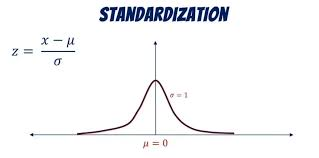


In [1]:
import numpy as np

In [2]:
# load all data inside a numpy nd.array
data = np.genfromtxt(fname="afdb_macroeconomic_africa.csv", delimiter=",", names=True, dtype=None, encoding="utf-8")
data

array([('Angola', 'AGO', 2000,  3.05462423, 324.9968716 , nan,   8.71506351,         nan,         nan,  9.62386615, 28.70338216,         nan, 19381.00033566),
       ('Angola', 'AGO', 2001,  4.20599856, 152.56102247, nan, -16.01295133,         nan,         nan, 24.0090757 , 29.24667572,         nan, 19506.62523715),
       ('Angola', 'AGO', 2002, 13.66568876, 108.89743609, nan,  -0.86701486, 49.49753848, 41.07328249, 10.07135573, 13.71504835, 29.77416691, 21337.72190323),
       ...,
       ('Zimbabwe', 'ZWE', 2021,  8.46801677,  98.54610509, nan,   0.84338837, 19.75961734, 24.35494215,  0.57518467,         nan, 13.45656316, 14037.1379014 ),
       ('Zimbabwe', 'ZWE', 2022,  6.13926328, 104.70517063, nan,   0.74824332, 23.69921963, 31.36813262,  0.82625404,         nan, 12.41893042, 14711.60545103),
       ('Zimbabwe', 'ZWE', 2023,  5.35086879,          nan, nan,   0.37321111, 17.11707601, 23.1741852 ,  1.68432123,         nan, 10.02304326, 14471.89170647)],
      dtype=[('Country', '<

In [3]:
# extract columns name
columns = data.dtype.names[3:]
columns

('GDP_growth_annual_pct',
 'Inflation_CPI_pct',
 'Central_govt_debt_pct_GDP',
 'Current_account_balance_pct_GDP',
 'Exports_pct_GDP',
 'Imports_pct_GDP',
 'FDI_inflows_pct_GDP',
 'Tax_revenue_pct_GDP',
 'Gross_capital_formation_pct_GDP',
 'GDP_per_worker_USD')

In [4]:
# extract data as 2D array
data_matrix = np.column_stack([data[col].astype(float) for col in columns])
data_matrix

array([[3.05462423e+00, 3.24996872e+02,            nan, ...,
        2.87033822e+01,            nan, 1.93810003e+04],
       [4.20599856e+00, 1.52561022e+02,            nan, ...,
        2.92466757e+01,            nan, 1.95066252e+04],
       [1.36656888e+01, 1.08897436e+02,            nan, ...,
        1.37150483e+01, 2.97741669e+01, 2.13377219e+04],
       ...,
       [8.46801677e+00, 9.85461051e+01,            nan, ...,
                   nan, 1.34565632e+01, 1.40371379e+04],
       [6.13926328e+00, 1.04705171e+02,            nan, ...,
                   nan, 1.24189304e+01, 1.47116055e+04],
       [5.35086879e+00,            nan,            nan, ...,
                   nan, 1.00230433e+01, 1.44718917e+04]])

In [5]:
# check for NAN values
print(np.isnan(data_matrix).sum(axis=0))

[  29  103 1022  213  192  192   35  582  198   73]


In [6]:
# check columns name with the highest NAN values
columns

('GDP_growth_annual_pct',
 'Inflation_CPI_pct',
 'Central_govt_debt_pct_GDP',
 'Current_account_balance_pct_GDP',
 'Exports_pct_GDP',
 'Imports_pct_GDP',
 'FDI_inflows_pct_GDP',
 'Tax_revenue_pct_GDP',
 'Gross_capital_formation_pct_GDP',
 'GDP_per_worker_USD')

### By matching column name with the corresponding NAN values inside the list, we see that Central_govt_debt_pct_GDP is 89% empty and Tax_revenue is 51%, the two features will be discarded in this PCA implementation

In [7]:
X = np.delete(data_matrix, [2,7], axis=1)
print(np.isnan(X).sum(axis=0))

[ 29 103 213 192 192  35 198  73]


In [8]:
# clean the remaining NAN values
col_means = np.nanmean(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
print(np.isnan(X).sum())  # should print 0

0


In [9]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # Do not use sklearn
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.82567029e-01,  9.33645489e+00,  1.67233409e+00,
         2.10636361e-16,  0.00000000e+00,  7.02534714e-01,
         0.00000000e+00,  1.15721031e-01],
       [ 2.82755016e-02,  4.21044258e+00, -1.18512350e+00,
         2.10636361e-16,  0.00000000e+00,  2.59264159e+00,
         0.00000000e+00,  1.22612774e-01],
       [ 1.76055751e+00,  2.91245216e+00,  5.65072438e-01,
         1.16233385e+00,  1.65278341e-01,  7.61331434e-01,
         8.32031974e-01,  2.23066166e-01],
       [-1.03332095e-01,  2.59516646e+00,  2.56508188e-01,
         1.04772388e+00,  2.82492540e-01,  1.74844335e+00,
         8.35827731e-01,  2.20778460e-01],
       [ 1.34929638e+00,  9.69629800e-01,  9.56840903e-01,
         1.25403228e+00,  6.59392195e-02,  5.07367654e-01,
         1.17112806e+00,  3.04593112e-01]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [10]:
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)
cov_matrix

array([[ 1.00086881, -0.11048218, -0.00126636, -0.01118254,  0.0249997 ,
         0.13693339,  0.14340977, -0.04825603],
       [-0.11048218,  1.00086881,  0.00954743, -0.07175537, -0.09488247,
        -0.00268553, -0.11139929, -0.04127116],
       [-0.00126636,  0.00954743,  1.00086881,  0.13475438, -0.18893228,
        -0.47692907, -0.19656094,  0.17118056],
       [-0.01118254, -0.07175537,  0.13475438,  1.00086881,  0.6364522 ,
         0.17434928,  0.25236051,  0.53667603],
       [ 0.0249997 , -0.09488247, -0.18893228,  0.6364522 ,  1.00086881,
         0.28165677,  0.3789168 ,  0.11818003],
       [ 0.13693339, -0.00268553, -0.47692907,  0.17434928,  0.28165677,
         1.00086881,  0.31803176,  0.05217522],
       [ 0.14340977, -0.11139929, -0.19656094,  0.25236051,  0.3789168 ,
         0.31803176,  1.00086881,  0.10575592],
       [-0.04825603, -0.04127116,  0.17118056,  0.53667603,  0.11818003,
         0.05217522,  0.10575592,  1.00086881]])

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

In [11]:
cov_matrix.shape

(8, 8)

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [12]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors


(array([2.28147376, 1.61197066, 0.19594587, 1.11149777, 0.45201041,
        0.90316745, 0.66799165, 0.78289291]),
 array([[-0.09475294,  0.17684559,  0.00781654, -0.67677483, -0.20000187,
         -0.63347845,  0.24524131, -0.01494163],
        [ 0.12362653,  0.0130144 , -0.00809911,  0.64975576, -0.08753513,
         -0.70220682, -0.06805722, -0.23855894],
        [ 0.1962971 , -0.59669098, -0.21235322, -0.2429864 ,  0.62650034,
         -0.18231828, -0.13235198, -0.24089699],
        [-0.50177723, -0.41331468,  0.70997888,  0.07699086,  0.04247977,
         -0.03255909,  0.23937265, -0.08502405],
        [-0.52583462, -0.03706844, -0.56252303,  0.0861127 , -0.10850809,
          0.14504474,  0.33462989, -0.50347511],
        [-0.38454587,  0.41727033, -0.08866154,  0.14450584,  0.67599396,
         -0.15438537,  0.12839136,  0.38984628],
        [-0.42489786,  0.17025826,  0.06870875, -0.14715939, -0.0200158 ,
         -0.04408715, -0.83989936, -0.23732239],
        [-0.28374227, -0.

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [13]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-0.09475294,  0.17684559, -0.67677483, -0.63347845, -0.01494163,
         0.24524131, -0.20000187,  0.00781654],
       [ 0.12362653,  0.0130144 ,  0.64975576, -0.70220682, -0.23855894,
        -0.06805722, -0.08753513, -0.00809911],
       [ 0.1962971 , -0.59669098, -0.2429864 , -0.18231828, -0.24089699,
        -0.13235198,  0.62650034, -0.21235322],
       [-0.50177723, -0.41331468,  0.07699086, -0.03255909, -0.08502405,
         0.23937265,  0.04247977,  0.70997888],
       [-0.52583462, -0.03706844,  0.0861127 ,  0.14504474, -0.50347511,
         0.33462989, -0.10850809, -0.56252303],
       [-0.38454587,  0.41727033,  0.14450584, -0.15438537,  0.38984628,
         0.12839136,  0.67599396, -0.08866154],
       [-0.42489786,  0.17025826, -0.14715939, -0.04408715, -0.23732239,
        -0.83989936, -0.0200158 ,  0.06870875],
       [-0.28374227, -0.48704274,  0.06978589, -0.1565059 ,  0.64483851,
        -0.16283784, -0.29813952, -0.3488488 ]])

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [14]:
# Step 6: Project Data onto Principal Components
# sort eigenvalues in decreasing order
eigenvalues_sorted = eigenvalues[sorted_indices]
# compute the explained variance
explained_variance = eigenvalues_sorted/eigenvalues_sorted.sum()
explained_variance

array([0.28493666, 0.20132142, 0.13881662, 0.11279793, 0.09777666,
       0.08342647, 0.05645225, 0.02447197])

In [15]:
num_components = np.argmax(explained_variance.cumsum() >= 0.85) + 1   # Decide on the number of principal components to keep

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]   # Project data onto the principal components
reduced_data[:5]

array([[ 1.19681482, -0.67185871,  5.89321372, -6.87193917, -2.27892526,
        -0.83016728],
       [-0.74657312,  1.78906404,  3.38780056, -3.17789928,  0.3704286 ,
         0.19014352],
       [-1.07557005, -0.12376066,  0.67044067, -3.46644534, -0.79607714,
        -0.14510079],
       [-1.38343634,  0.18328494,  1.94388788, -2.1381264 , -0.28502799,
        -0.40406084],
       [-1.26321258, -0.57770246, -0.49118798, -1.91897889, -0.50552244,
        -0.507568  ]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [16]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1152, 6)


array([[ 1.19681482, -0.67185871,  5.89321372, -6.87193917, -2.27892526,
        -0.83016728],
       [-0.74657312,  1.78906404,  3.38780056, -3.17789928,  0.3704286 ,
         0.19014352],
       [-1.07557005, -0.12376066,  0.67044067, -3.46644534, -0.79607714,
        -0.14510079],
       [-1.38343634,  0.18328494,  1.94388788, -2.1381264 , -0.28502799,
        -0.40406084],
       [-1.26321258, -0.57770246, -0.49118798, -1.91897889, -0.50552244,
        -0.507568  ]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

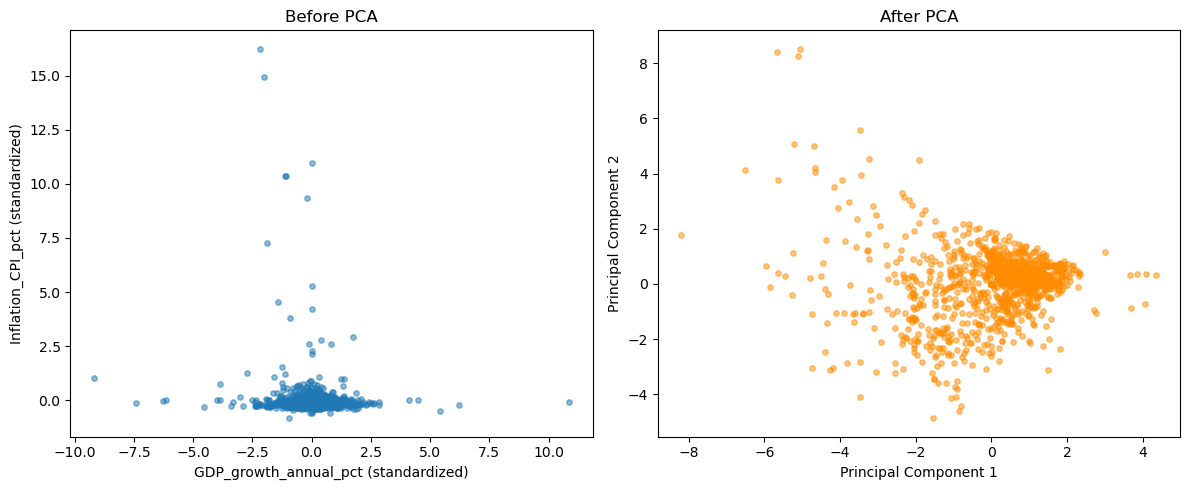

In [17]:
import matplotlib.pyplot as plt

# Step 8: Visualize Before and After PCA
plt.figure(figsize=(12, 5))

# Plot original data (first two features for simplicity)
plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.5, s=15)
plt.xlabel('GDP_growth_annual_pct (standardized)')
plt.ylabel('Inflation_CPI_pct (standardized)')
plt.title('Before PCA')

# Plot reduced data after PCA
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, s=15, color='darkorange')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
